In [85]:
import pandas as pd

In [86]:

def profile_dataset(df: pd.DataFrame) -> dict:
    profile = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": list(df.columns),
        "dtypes": df.dtypes.to_dict(),
        "missing_values": df.isna().sum().to_dict(),
        "duplicates": int(df.duplicated().sum()),
        "numeric_columns": list(
            df.select_dtypes(include="number").columns
        ),
        "categorical_columns": list(
            df.select_dtypes(include="object").columns
        ),
    }

    return profile

In [99]:
def metric_dataset(df : pd.DataFrame,col) -> dict:

    """
    df : The dataframe 
    col : The column we want to calculate its metrics

    Calculates differents metrics like mean , max etc for the column in the df 

    Returns a dict of the different metrics for the column
    
    """
    metrics = ["mean","median","max","min","std"]


    metric_dict = {"Column":col}
    for metric in metrics:
        metric_dict[f"{metric}"] = df[col].agg(metric)

    return metric_dict



In [88]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [97]:
df_2 = pd.read_csv("../data/raw/customer_master.csv")

df_2

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34
...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST-024996,Nathan Porter,40,Male,Consumer,Kristineport,Texas,USA,South,62079,14.92
24996,CUST-024997,Heather Graham,19,Female,Consumer,Ruizside,North Rhine,Germany,West,16488,11.41
24997,CUST-024998,John Smith,31,Female,Business,Jacksonside,North Carolina,USA,South,86726,66.95
24998,CUST-024999,Eric Castillo,52,Female,Consumer,West Brandonfort,Ontario,Canada,East,92053,24.97


In [ ]:
def categorical_count(df:pd.DataFrame,categorical_column:str):
    return df.groupby(categorical_column)[categorical_column].value_counts()

In [105]:
categorical_count(df_2,"customer_country")

customer_country  customer_id  customer_name      customer_age  gender  customer_segment  customer_city      customer_state     region   customer_postal_code  customer_acquisition_cost
Australia         CUST-000033  Adam Lewis         50            Female  Consumer          Karenland          Victoria           South    76175                 74.18                        1
                  CUST-000056  Tracy Ray          57            Female  Consumer          Courtneyfurt       Queensland         North    59744                 29.51                        1
                  CUST-000084  Cynthia Davenport  49            Male    Consumer          West Hollybury     Western Australia  West     8090                  71.33                        1
                  CUST-000095  Nathan Shaw        29            Male    Consumer          East Jeffreyhaven  South Australia    South    6520                  36.50                        1
                  CUST-000125  John Ferguson      49   

In [100]:
metric_dataset(df_2,"gender")

TypeError: Cannot perform reduction 'mean' with string dtype

In [89]:
metric_dataset(df,"std")

{'Metric': 'std',
 'UDI': 2886.8956799071675,
 'Air temperature [K]': 2.0002586829157516,
 'Process temperature [K]': 1.4837342191657208,
 'Rotational speed [rpm]': 179.2840959134266,
 'Torque [Nm]': 9.968933725121337,
 'Tool wear [min]': 63.65414663663636,
 'Machine failure': 0.18098084265065362,
 'TWF': 0.06767051004531426,
 'HDF': 0.10662498247919606,
 'PWF': 0.09700871645943425,
 'OSF': 0.10104836009113513,
 'RNF': 0.043549737748530666}

In [90]:
profile_dataset(df)

/var/folders/cl/jjptsfwd2x357nx1tsybxqzc0000gn/T/ipykernel_26684/2582647713.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


{'rows': 10000,
 'columns': 14,
 'column_names': ['UDI',
  'Product ID',
  'Type',
  'Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'Machine failure',
  'TWF',
  'HDF',
  'PWF',
  'OSF',
  'RNF'],
 'dtypes': {'UDI': dtype('int64'),
  'Product ID': <StringDtype(na_value=nan)>,
  'Type': <StringDtype(na_value=nan)>,
  'Air temperature [K]': dtype('float64'),
  'Process temperature [K]': dtype('float64'),
  'Rotational speed [rpm]': dtype('int64'),
  'Torque [Nm]': dtype('float64'),
  'Tool wear [min]': dtype('int64'),
  'Machine failure': dtype('int64'),
  'TWF': dtype('int64'),
  'HDF': dtype('int64'),
  'PWF': dtype('int64'),
  'OSF': dtype('int64'),
  'RNF': dtype('int64')},
 'missing_values': {'UDI': 0,
  'Product ID': 0,
  'Type': 0,
  'Air temperature [K]': 0,
  'Process temperature [K]': 0,
  'Rotational speed [rpm]': 0,
  'Torque [Nm]': 0,
  'Tool wear [min]': 0,
  'Machine failure': 0,
  'TWF': 0,
  'HDF': 

In [91]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [96]:
df[df["OSF"] == -2]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
20,21,H29434,H,298.9,309.3,1375,42.7,58,0,0,0,0,-2,0


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [81]:
df["Product ID"].unique()

<ArrowStringArray>
['M14860', 'L47181', 'L47182', 'L47183', 'L47184', 'M14865', 'L47186',
 'L47187', 'M14868', 'M14869',
 ...
 'L57170', 'M24851', 'L57172', 'L57173', 'L57174', 'M24855', 'H39410',
 'M24857', 'H39412', 'M24859']
Length: 10000, dtype: str

In [ ]:
import matplotlib.pyplot as plt

def categorical_viz(df : pd.DataFrame , col):

    plt.figure(figsize=(6,6))


    X_cat = df[col].unique().tolist()
    Y_cat = df[col].value_counts().tolist()

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")


    plt.grid()
    plt.bar(X_cat,Y_cat)
    return plt.show()

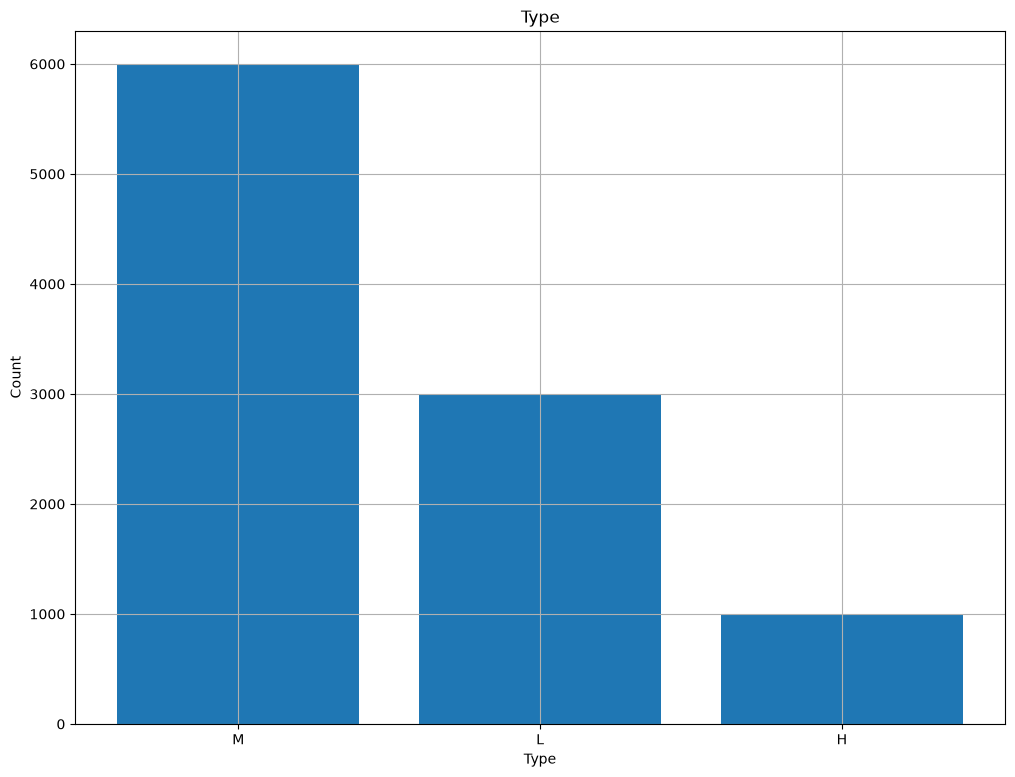

In [53]:
categorical_viz(df,"Type")

In [64]:
def numerical_viz(df: pd.DataFrame, x_col: str, y_col: str):
    fig, ax = plt.subplots(figsize=(6,6))

    
    X_val = df[x_col]
    Y_val = df[y_col]

    ax.scatter(X_val,Y_val)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    
    return fig

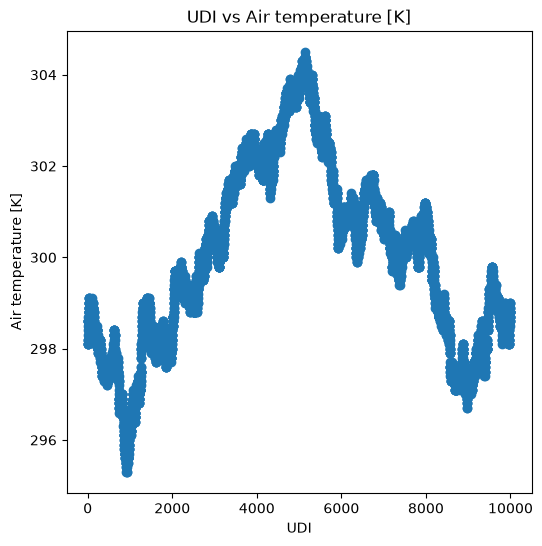

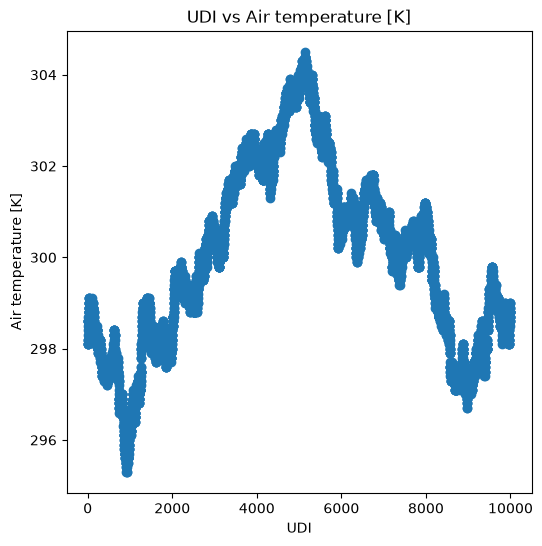

In [70]:
numerical_viz(df,"UDI" , "Air temperature [K]")